cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,3.621000
100,3.595900
150,3.522100
200,3.568400
250,3.622200
300,3.513100
350,3.515200
400,3.429600
450,3.479700
500,3.465900


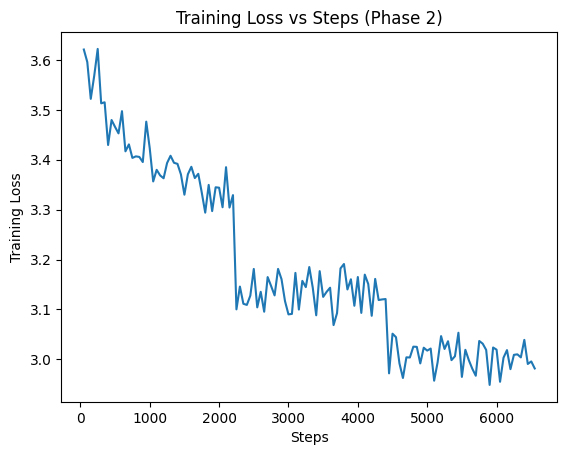

Perplexity 16.80
Prompt: We performed Cox proportional hazards regression to estimate the hazard ratio (HR) for
We performed Cox proportional hazards regression to estimate the hazard ratio (HR) for each period. The HR varied significantly among all age groups, and the logistic regression suggested a trend toward an HR greater than or equal to 0.93 for the 10-year-old and 0.95 and 0.95, respectively. There was no significant interaction between age at diagnosis and duration of treatment. There was little difference between the risk ratios for the 10-year-old and those for the age at diagnosis. There was a significant risk reduction (p less than 0.05) for the patients with endocrine disordered eyes. There was no significant difference in endocrine disordered eyes between 10 and 20 year old age groups. None of these findings indicate that endocrine disordered eyes are an autosomal dominant disorder. It is concluded that the pathogenesis of polyglial anastomosis is not yet fully understoo

In [ ]:
import torch
import math
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TextDataset, DataCollatorForLanguageModeling, Trainer, TrainingArguments

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id #AI suggested adding this line to avoid warnings about missing pad_token_id.

train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path="pretrain.txt",
    block_size=128
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./gpt2trained",
        overwrite_output_dir=True,
        #parametreler
        num_train_epochs=3,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        #eval
        logging_steps=50,
        save_steps=200,
        save_total_limit=2,
        fp16=True,
        report_to="none"
        ),
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=train_dataset,
)

trainer.train()
trainer.save_model("./gpt2domain")
tokenizer.save_pretrained("./gpt2domain")
#saved to gpt2domain

#loss step
log_history = trainer.state.log_history
steps = []
losses = []
for row in log_history:
    if "loss" in row and "step" in row:
        steps.append(row["step"])
        losses.append(row["loss"])

if len(steps) > 0:
    plt.figure()
    plt.plot(steps, losses)
    plt.xlabel("Steps")
    plt.ylabel("Training Loss")
    plt.title("Training Loss vs Steps (Phase 2)")
    plt.show()
else:
    print("No loss logs found. Try lowering logging_steps or ensure training ran.") #AI suggested this message to help debug potential logging issues.

eval_results = trainer.evaluate()
perplexity = math.exp(eval_results['eval_loss'])
print(f"Perplexity {perplexity:.2f}")

input_text = "We performed Cox proportional hazards regression to estimate the hazard ratio (HR) for"
inputs = tokenizer(input_text, return_tensors="pt").to(device)
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

print(f"Prompt: {input_text}")

output = model.generate(
    input_ids,
    attention_mask=inputs["attention_mask"],
    max_new_tokens=512,
    num_return_sequences=1,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)